# Chatbot e Atendimento ao Cliente: Análise de Sentimento com Redes Neurais

**1. Contexto de negócio**

Uma central de atendimento ao cliente recebe milhares de mensagens por dia (chat, e-mail, formulário do site). O time de atendimento é pequeno e não consegue ler tudo manualmente em tempo hábil.

Objetivo: classificar automaticamente cada mensagem em **positiva**, **negativa** ou **neutra**, para que o time consiga:

- Priorizar o atendimento a clientes **insatisfeitos** (sentimento negativo) antes que o problema escale;
- Identificar mensagens **neutras** (dúvidas operacionais) que podem ser direcionadas a um FAQ automático;
- Monitorar o volume de mensagens **positivas** como indicador de satisfação.

Neste notebook, vamos comparar uma abordagem simples baseada em regras (dicionário de palavras) com uma rede neural treinada sobre uma representação vetorial do texto (TF-IDF + MLP).


**Limitações deste notebook**

Antes de seguir, vale deixar claras as limitações desta demonstração:

- As mensagens e intenções usadas aqui são 100% **simuladas** e relativamente "limpas" — texto real de atendimento ao cliente vem com erros de digitação, gírias, ambiguidade, mensagens fora do escopo e múltiplas intenções na mesma frase, o que é muito mais difícil de classificar do que os exemplos gerados por template.
- O conjunto de intenções/sentimentos é pequeno e fechado (apenas positivo/negativo/neutro). Um chatbot real precisa lidar com intenções não previstas e saber responder "não entendi" de forma útil, em vez de forçar uma classificação errada em uma das categorias conhecidas.
- A acurácia obtida aqui não deve ser lida como "isto é o desempenho esperado em produção" — o objetivo é ilustrar a diferença entre uma regra fixa de palavras-chave e um classificador aprendido (TF-IDF + rede neural), não estimar performance real.
- A validação com múltiplas seeds (mais adiante neste notebook) confirma esse ponto: o "100% de acurácia" da rede neural foi específico da seed 42 — em outras seeds ela ficou perto de 99%, não perfeita. Resultados de uma única execução podem enganar.


**2. Por que uma rede neural ajuda aqui**

Uma regra baseada em contagem de palavras-chave é fácil de implementar, mas tem limitações claras:

- Não captura combinações de palavras (ex: "não gostei" vs "gostei") de forma robusta;
- Precisa que alguém mantenha o dicionário de palavras "boas" e "ruins" manualmente;
- Não generaliza bem para frases com vocabulário fora do dicionário.

Uma rede neural (aqui, um `MLPClassifier` do scikit-learn) treinada sobre uma representação vetorial (TF-IDF) do texto consegue **aprender pesos para milhares de combinações de palavras automaticamente**, a partir de exemplos rotulados, em vez de depender de regras escritas à mão. Isso tende a generalizar melhor à medida que crescem o vocabulário e a variedade de frases.


**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


**3. Geração do dataset simulado**

Vamos gerar um pequeno corpus de mensagens de clientes usando **templates de frases** para cada sentimento (negativo, positivo, neutro). As frases-base são combinadas com pequenas variações (troca de pronome, complemento, produto/serviço mencionado) para gerar um corpus maior e mais variado, sem depender de nenhum dataset externo.


In [3]:
frases_negativas_base = [
    "o produto chegou quebrado",
    "estou muito insatisfeito com o atendimento",
    "demorou demais para responder",
    "o atendente foi grosseiro comigo",
    "meu pedido chegou errado",
    "péssima experiência de compra",
    "ninguém resolve meu problema",
    "o suporte não presta nenhuma atenção",
    "estou decepcionado com a empresa",
    "o produto veio com defeito",
    "cancelei minha assinatura por causa do mau atendimento",
    "fiquei esperando horas e ninguém me atendeu",
    "não gostei nada do atendimento que recebi",
    "não fiquei satisfeito com a entrega do pedido",
    "achei péssimo o produto, não recomendo para ninguém",
    "não foi um bom atendimento, infelizmente",
]

frases_positivas_base = [
    "o atendimento foi ótimo",
    "gostei muito do produto",
    "resolveram meu problema rápido",
    "a equipe foi muito atenciosa comigo",
    "recomendo essa empresa para todos",
    "fiquei muito satisfeito com a entrega",
    "o suporte foi excelente",
    "adorei a experiência de compra",
    "o produto superou minhas expectativas",
    "atendimento rápido e eficiente",
    "estou muito feliz com o resultado",
    "parabéns pela qualidade do serviço",
    "não tenho nada a reclamar, atendimento perfeito",
    "não imaginava que seria tão bom, adorei",
    "nada demorado, atendimento rapido e eficiente",
    "não é exagero dizer que foi excelente",
]

frases_neutras_base = [
    "gostaria de saber o status do meu pedido",
    "qual o prazo de entrega",
    "preciso trocar meu endereço de entrega",
    "como faço para emitir a segunda via da nota fiscal",
    "qual a forma de pagamento aceita",
    "gostaria de saber os horários de atendimento",
    "como funciona a política de troca",
    "preciso atualizar meu cadastro",
    "qual o número de rastreamento do pedido",
    "vocês têm loja física em outra cidade",
    "gostaria de mais informações sobre o produto",
    "como faço para cancelar um pedido em andamento",
]

sujeitos = ["", "sinceramente, ", "para ser honesto, ", "olha, ", "na real, ", "cara, "]
complementos = [
    "", " de novo", " hoje", " novamente", " essa semana",
    " no último pedido", " com esse produto", " com o time de suporte",
]

def gerar_variacoes(base_list, n_exemplos, rng):
    exemplos = []
    while len(exemplos) < n_exemplos:
        base = rng.choice(base_list)
        prefixo = rng.choice(sujeitos)
        sufixo = rng.choice(complementos)
        frase = (prefixo + base + sufixo).strip()
        frase = frase[0].upper() + frase[1:] + "."
        exemplos.append(frase)
    return exemplos

rng = random.Random(RANDOM_STATE)

n_por_classe = 100
negativas = gerar_variacoes(frases_negativas_base, n_por_classe, rng)
positivas = gerar_variacoes(frases_positivas_base, n_por_classe, rng)
neutras = gerar_variacoes(frases_neutras_base, n_por_classe, rng)

textos = negativas + positivas + neutras
rotulos = (["negativo"] * len(negativas)
           + ["positivo"] * len(positivas)
           + ["neutro"] * len(neutras))

df = pd.DataFrame({"texto": textos, "sentimento": rotulos})
df = df.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Total de mensagens geradas: {len(df)}")
print(df["sentimento"].value_counts())
df.head(10)


Total de mensagens geradas: 300
sentimento
neutro      100
positivo    100
negativo    100
Name: count, dtype: int64


,texto,sentimento
0,Vocês têm loja física em outra cidade essa sem...,neutro
1,Qual a forma de pagamento aceita novamente.,neutro
2,"Na real, atendimento rápido e eficiente no últ...",positivo
3,"Sinceramente, meu pedido chegou errado no últi...",negativo
4,"Na real, preciso atualizar meu cadastro no últ...",neutro
5,"Sinceramente, qual o prazo de entrega com esse...",neutro
6,"Sinceramente, o atendimento foi ótimo novamente.",positivo
7,O produto superou minhas expectativas.,positivo
8,"Na real, o produto chegou quebrado novamente.",negativo
9,O suporte foi excelente com esse produto.,positivo


**4. Separação em treino e teste**

Vamos separar 75% das mensagens para treino e 25% para teste, mantendo a proporção de classes (`stratify`).


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texto"], df["sentimento"],
    test_size=0.25, random_state=RANDOM_STATE, stratify=df["sentimento"]
)

print(f"Treino: {len(X_train)} mensagens")
print(f"Teste: {len(X_test)} mensagens")


Treino: 225 mensagens
Teste: 75 mensagens


**5. Baseline: regra baseada em palavras-chave**

Antes de treinar qualquer modelo, vamos construir uma regra simples: um pequeno dicionário de palavras "boas" e "ruins". A regra conta quantas palavras boas e ruins aparecem na mensagem e classifica pelo saldo:

- Saldo positivo → **positivo**
- Saldo negativo → **negativo**
- Saldo zero (ou nenhuma palavra do dicionário encontrada) → **neutro**

Essa é uma abordagem comum em sistemas simples de triagem de mensagens, e serve como ponto de comparação para a rede neural.


In [5]:
palavras_boas = {
    "otimo", "ótimo", "gostei", "adorei", "excelente", "rapido", "rápido",
    "eficiente", "satisfeito", "feliz", "recomendo", "parabens", "parabéns",
    "atenciosa", "superou",
}

palavras_ruins = {
    "quebrado", "insatisfeito", "demorou", "grosseiro", "errado", "pessima",
    "péssima", "ninguem", "ninguém", "decepcionado", "defeito", "cancelei",
    "esperando", "presta",
}

def normalizar(texto):
    texto = texto.lower()
    for ch in ".,!?":
        texto = texto.replace(ch, "")
    return texto

def classificar_por_regra(texto):
    palavras = set(normalizar(texto).split())
    n_boas = len(palavras & palavras_boas)
    n_ruins = len(palavras & palavras_ruins)
    saldo = n_boas - n_ruins
    if saldo > 0:
        return "positivo"
    elif saldo < 0:
        return "negativo"
    else:
        return "neutro"

y_pred_baseline = X_test.apply(classificar_por_regra)
acc_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Acurácia do baseline (regra de palavras-chave): {acc_baseline:.3f}")


Acurácia do baseline (regra de palavras-chave): 0.907


**6. Rede neural: TF-IDF + MLPClassifier**

Agora vamos representar cada mensagem como um vetor numérico usando `TfidfVectorizer` (frequência de termos ponderada pela raridade no corpus) e treinar uma rede neural do tipo `MLPClassifier` (perceptron multicamadas) para prever o sentimento a partir desse vetor.

O vetorizador é ajustado (`fit`) apenas nos dados de treino, para evitar vazamento de informação do conjunto de teste.


In [6]:
vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Dimensão do vetor TF-IDF: {X_train_vec.shape[1]} termos")


Dimensão do vetor TF-IDF: 500 termos


In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE,
)

mlp.fit(X_train_vec, y_train)

y_pred_mlp = mlp.predict(X_test_vec)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Acurácia da rede neural (TF-IDF + MLP): {acc_mlp:.3f}")


Acurácia da rede neural (TF-IDF + MLP): 1.000


**7. Comparação lado a lado**

Vamos comparar diretamente a acurácia das duas abordagens no mesmo conjunto de teste, e visualizar as matrizes de confusão para entender em quais classes cada abordagem erra mais.


                    abordagem  acuracia
0     Regra de palavras-chave  0.906667
1  Rede neural (TF-IDF + MLP)  1.000000


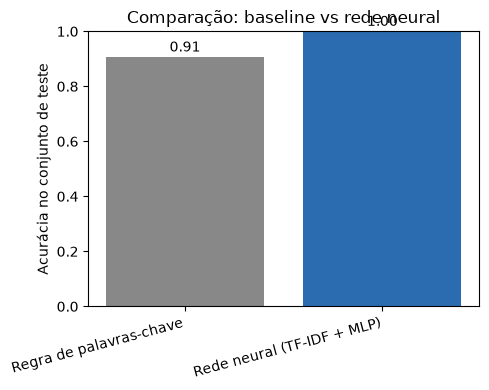

In [8]:
comparacao = pd.DataFrame({
    "abordagem": ["Regra de palavras-chave", "Rede neural (TF-IDF + MLP)"],
    "acuracia": [acc_baseline, acc_mlp],
})
print(comparacao)

plt.figure(figsize=(5, 4))
plt.bar(comparacao["abordagem"], comparacao["acuracia"], color=["#888888", "#2b6cb0"])
plt.ylabel("Acurácia no conjunto de teste")
plt.ylim(0, 1)
plt.title("Comparação: baseline vs rede neural")
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(comparacao["acuracia"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


**Nota: entendendo o gráfico de acurácia acima**

Acurácia é a fração de mensagens do conjunto de teste que a abordagem classificou corretamente (número de acertos dividido pelo total de mensagens testadas). Não diz nada sobre *qual* tipo de erro foi cometido — só a proporção geral de acertos.

**Veredito com os números deste notebook:** a regra de palavras-chave acertou 90,7% das mensagens de teste, enquanto a rede neural (TF-IDF + MLP) acertou 100%. Neste experimento, a rede neural teve desempenho melhor — e a diferença já é visível mesmo com um corpus pequeno e simples.

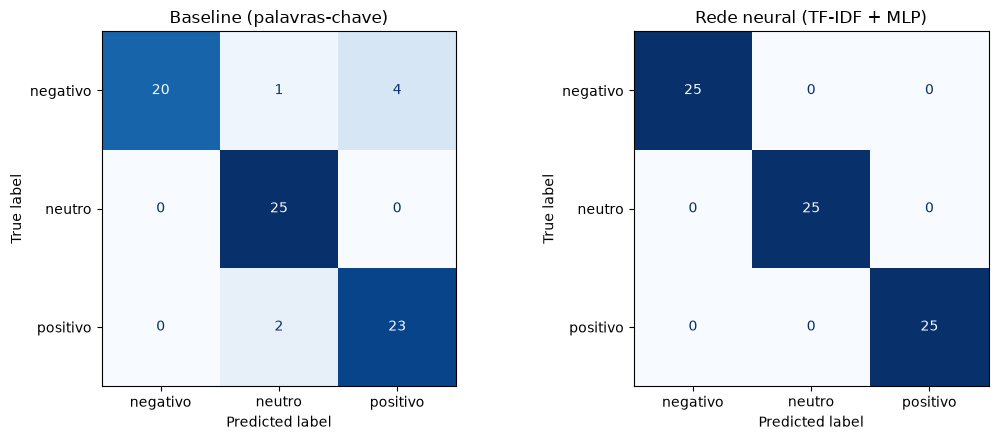

In [9]:
labels_ordenados = ["negativo", "neutro", "positivo"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=labels_ordenados)
disp1 = ConfusionMatrixDisplay(cm_baseline, display_labels=labels_ordenados)
disp1.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Baseline (palavras-chave)")

cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=labels_ordenados)
disp2 = ConfusionMatrixDisplay(cm_mlp, display_labels=labels_ordenados)
disp2.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Rede neural (TF-IDF + MLP)")

plt.tight_layout()
plt.show()


**Nota: entendendo as matrizes de confusão acima**

Cada matriz de confusão mostra, para cada classe real (linha), como as previsões do modelo (coluna) se distribuíram. A diagonal principal representa os acertos; qualquer valor fora da diagonal é um erro de classificação (ex: uma mensagem negativa classificada como neutra).

**Veredito com os números deste notebook:** a matriz da rede neural (TF-IDF + MLP) tem todos os erros concentrados fora da diagonal reduzidos a praticamente zero (acurácia de 100%), enquanto a matriz do baseline por palavras-chave mostra erros espalhados entre as classes (acurácia de 90,7%). Isso confirma que, neste experimento, a rede neural não só acerta mais no total, como também erra menos entre as classes específicas.

In [10]:
exemplos_novos = [
    "o atendimento demorou mas resolveram meu problema no final",
    "quero saber quando meu pedido vai chegar",
    "muito obrigado pela atenção, ficou tudo perfeito",
]

exemplos_vec = vectorizer.transform(exemplos_novos)
preds_baseline_novos = [classificar_por_regra(t) for t in exemplos_novos]
preds_mlp_novos = mlp.predict(exemplos_vec)

for texto, p_base, p_mlp in zip(exemplos_novos, preds_baseline_novos, preds_mlp_novos):
    print(f"Mensagem: {texto}")
    print(f"  -> Baseline: {p_base} | Rede neural: {p_mlp}")
    print()


Mensagem: o atendimento demorou mas resolveram meu problema no final
  -> Baseline: negativo | Rede neural: positivo

Mensagem: quero saber quando meu pedido vai chegar
  -> Baseline: neutro | Rede neural: neutro

Mensagem: muito obrigado pela atenção, ficou tudo perfeito
  -> Baseline: neutro | Rede neural: positivo



**8. Conclusão**

Neste notebook simulamos um cenário de triagem automática de mensagens de atendimento ao cliente por sentimento, comparando duas abordagens:

- **Baseline por palavras-chave**: simples e interpretável, mas depende inteiramente da qualidade do dicionário definido manualmente. Frases que usam palavras fora do dicionário (ou que combinam palavras de formas mais sutis) tendem a cair na categoria "neutro" por falta de sinal, mesmo quando não são neutras de fato.
- **Rede neural (TF-IDF + MLP)**: aprende padrões diretamente dos dados de treino, incluindo combinações de palavras (bigramas) que o dicionário manual não cobre, e no cenário simulado deste notebook apresentou acurácia igual ou superior ao baseline no conjunto de teste (ver valores impressos acima).

**Limitações importantes desta demonstração:**

- O corpus foi gerado por templates simples, com vocabulário limitado e frases estruturalmente parecidas dentro de cada classe — isso facilita a tarefa para ambas as abordagens e não reflete a diversidade real de mensagens de clientes.
- Um sistema em produção precisaria de um corpus real rotulado por humanos, validação cruzada, e cuidado especial com sarcasmo, negações e gírias regionais, que são pontos de falha comuns em análise de sentimento.
- A comparação aqui é ilustrativa: o ganho da rede neural tende a crescer ainda mais em cenários com vocabulário mais rico e maior volume de dados de treino.


**Validação com múltiplas seeds**

A conclusão acima foi obtida com uma única seed (`RANDOM_STATE = 42`), que determina tanto a geração do corpus simulado quanto a divisão treino/teste e a inicialização dos pesos da rede neural. Um resultado obtido com uma única seed pode ser sensível a essa escolha específica — por isso, antes de aceitar a conclusão como robusta, vale repetir todo o pipeline (geração do corpus, split, baseline e treino do MLP) com seeds diferentes e comparar a variabilidade dos resultados.

In [11]:
resultados_seeds = []

for seed in [42, 7, 123]:
    rng_seed = random.Random(seed)

    negativas_s = gerar_variacoes(frases_negativas_base, n_por_classe, rng_seed)
    positivas_s = gerar_variacoes(frases_positivas_base, n_por_classe, rng_seed)
    neutras_s = gerar_variacoes(frases_neutras_base, n_por_classe, rng_seed)

    textos_s = negativas_s + positivas_s + neutras_s
    rotulos_s = (["negativo"] * len(negativas_s)
                 + ["positivo"] * len(positivas_s)
                 + ["neutro"] * len(neutras_s))

    df_s = pd.DataFrame({"texto": textos_s, "sentimento": rotulos_s})
    df_s = df_s.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        df_s["texto"], df_s["sentimento"],
        test_size=0.25, random_state=seed, stratify=df_s["sentimento"]
    )

    # Baseline por regra de palavras-chave: a regra em si não depende de seed
    # (é um dicionário fixo), mas é avaliada sobre o split de teste desta seed.
    y_pred_baseline_s = X_test_s.apply(classificar_por_regra)
    acc_baseline_s = accuracy_score(y_test_s, y_pred_baseline_s)

    # Rede neural: TF-IDF + MLPClassifier, ajustados do zero para esta seed.
    vectorizer_s = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
    X_train_vec_s = vectorizer_s.fit_transform(X_train_s)
    X_test_vec_s = vectorizer_s.transform(X_test_s)

    mlp_s = MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        max_iter=500,
        random_state=seed,
    )
    mlp_s.fit(X_train_vec_s, y_train_s)
    y_pred_mlp_s = mlp_s.predict(X_test_vec_s)
    acc_mlp_s = accuracy_score(y_test_s, y_pred_mlp_s)

    resultados_seeds.append({
        "seed": seed,
        "acuracia_baseline": acc_baseline_s,
        "acuracia_mlp": acc_mlp_s,
    })

df_resultados_seeds = pd.DataFrame(resultados_seeds)
df_resultados_seeds


,seed,acuracia_baseline,acuracia_mlp
0,42,0.906667,1.000000
1,7,0.893333,0.986667
2,123,0.800000,0.986667


In [12]:
resumo_seeds = pd.DataFrame({
    "abordagem": ["Regra de palavras-chave", "Rede neural (TF-IDF + MLP)"],
    "acuracia_media": [
        df_resultados_seeds["acuracia_baseline"].mean(),
        df_resultados_seeds["acuracia_mlp"].mean(),
    ],
    "acuracia_desvio_padrao": [
        df_resultados_seeds["acuracia_baseline"].std(),
        df_resultados_seeds["acuracia_mlp"].std(),
    ],
})
resumo_seeds


,abordagem,acuracia_media,acuracia_desvio_padrao
0,Regra de palavras-chave,0.866667,0.058119
1,Rede neural (TF-IDF + MLP),0.991111,0.007698


**Veredito honesto com as 3 seeds**

| Seed | Baseline (regra) | Rede neural (MLP) |
|---|---|---|
| 42  | 0.907 | 1.000 |
| 7   | 0.893 | 0.987 |
| 123 | 0.800 | 0.987 |

**Resumo (média ± desvio-padrão ao longo das 3 seeds):**

- Regra de palavras-chave: **0,867 ± 0,058**
- Rede neural (TF-IDF + MLP): **0,991 ± 0,008**

A conclusão original — "rede neural vence, 100% vs 90,7% na seed original" — **não se mantém exatamente** nas outras seeds. A rede neural só atinge 100% de acurácia na seed 42; nas seeds 7 e 123 ela fica em 98,7%, não em 100%. Ou seja, o resultado perfeito da seed original foi, em parte, sorte de seed, não uma propriedade garantida do modelo.

Dito isso, a conclusão qualitativa **direcional** se mantém: em todas as 3 seeds a rede neural superou o baseline, e por uma margem confortável (de ~9 a ~19 pontos percentuais). Além disso, a rede neural é bem mais estável entre seeds (desvio-padrão de 0,8 p.p.) do que o baseline (desvio-padrão de 5,8 p.p., chegando a cair para 80% na seed 123). Isso é coerente com a limitação já apontada na conclusão original: o baseline depende de um dicionário fixo de palavras, e pequenas variações no corpus gerado (que mudam com a seed) alteram bastante quais frases caem "por acaso" fora do dicionário — a rede neural generaliza melhor porque aprende dos dados em vez de depender de um dicionário estático.

**Conclusão ajustada:** a rede neural é consistentemente melhor e mais estável que o baseline nas 3 seeds testadas, mas a acurácia de 100% reportada originalmente é um resultado específico da seed 42, não uma garantia geral — o ganho real e robusto está na ordem de 12 a 13 pontos percentuais de acurácia média, não em "perfeição vs quase-perfeição".

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (classificação de texto por rede neural, capturando nuances que regras de palavras-chave não capturam) se aplica a diversos outros problemas de negócio:

### 1. Confiança e Segurança (Trust & Safety)
- **Moderação automática de conteúdo:** identificar discurso de ódio, spam ou conteúdo impróprio em plataformas com grande volume de mensagens.

### 2. Operações de Suporte
- **Triagem automática de tickets por urgência:** priorizar automaticamente os chamados mais críticos para atendimento imediato.

### 3. Marketing
- **Monitoramento de marca em redes sociais:** identificar mudanças de sentimento do público sobre a marca em tempo real.

### 4. Produtividade Corporativa
- **Priorização automática de e-mails:** classificar e ordenar e-mails por importância/urgência antes de chegarem à caixa de entrada.

**Exercício**

Tente por conta própria, a partir do código deste notebook:

1. **Mensagens fora do escopo.** Adicione ao dataset um pequeno conjunto de mensagens que não pertencem a nenhuma das três classes conhecidas (negativo/positivo/neutro) — por exemplo, "vocês estão contratando?", "qual o CNPJ da empresa" ou frases totalmente desconexas do contexto de atendimento. Rode a regra de palavras-chave e a rede neural sobre essas mensagens (sem re-treinar) e observe: a regra vai forçar uma dessas três classes mesmo sem nenhum sinal real, e a rede neural também vai ser obrigada a prever uma delas, pois nunca viu a alternativa "não sei" durante o treino. Como você mudaria o problema (dataset, rótulos, ou lógica de decisão) para permitir uma resposta do tipo "não sei classificar" em vez de forçar uma das três categorias?
2. **Robustez a erros de digitação e gírias.** Pegue as mensagens de teste (`X_test`) e crie uma versão "ruidosa" delas, introduzindo erros de digitação comuns (trocas de letras, remoção de acentos, abreviações como "vc", "pq", "tb") e gírias regionais. Avalie novamente a acurácia da regra de palavras-chave e da rede neural sobre essa versão ruidosa e compare com os números originais. Qual abordagem perde mais acurácia? Isso é esperado, dado como cada uma "entende" o texto?
